# Generalizable ECG Classification

In [ ]:
# Imports
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

In [39]:
import matplotlib
matplotlib.use("inline")  
%matplotlib inline

In [35]:
# Loading data directories
LTDB_DIR  = Path("../raw_data/mit-bih-long-term-ecg-database-1.0.0")
PTBXL_DIR = Path("../raw_data/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3")

## Data Preprocessing and EDA

In [ ]:
ltdb_records = [p.stem for p in LTDB_DIR.glob("*.hea") if not p.name.endswith(".hea-")]

In [ ]:
# Annotation symbols across all records

all_symbols = []
for name in ltdb_records:
    ann = wfdb.rdann(str(LTDB_DIR / name), "atr")
    all_symbols.extend(ann.symbol)

counts = Counter(all_symbols)
print("All annotation symbols and counts:")
for sym, cnt in counts.most_common():
    print(f"  {sym:4s}  {cnt:>8,}")

All annotation symbols and counts:
  N      600,232
  V       64,095
  F        2,908
  S        1,350
  ~        1,117
  J          149
  a            1


### Annotation Symbols and Meanings

- **N** → Normal beat  
- **V** → Ventricular ectopic beat (PVC)  
- **F** → Fusion beat (normal + ventricular)  
- **S** → Supraventricular ectopic beat  
- **~** → Noise / signal artifact  
- **J** → Junctional beat  
- **a** → Aberrated atrial beat

Association for the Advancement of Medical Instrumentation (AAMI) defines a standard grouping of ECG beat types to simplify classification

In [ ]:
# AAMI mapping
AAMI_MAP = {
    "N":"N","L":"N","R":"N","e":"N","j":"N",
    "A":"S","a":"S","J":"S","S":"S",
    "V":"V","E":"V",
    "F":"F",
    "/":"Q","f":"Q","Q":"Q"
}

aami_counts = Counter()
for sym, cnt in counts.items():
    if sym in AAMI_MAP:
        aami_counts[AAMI_MAP[sym]] += cnt

print("AAMI class distribution:")
for cls, cnt in aami_counts.most_common():
    print(f"  {cls}  {cnt:>8,}")

AAMI class distribution:
  N   600,232
  V    64,095
  F     2,908
  S     1,500


R-peak used: 181


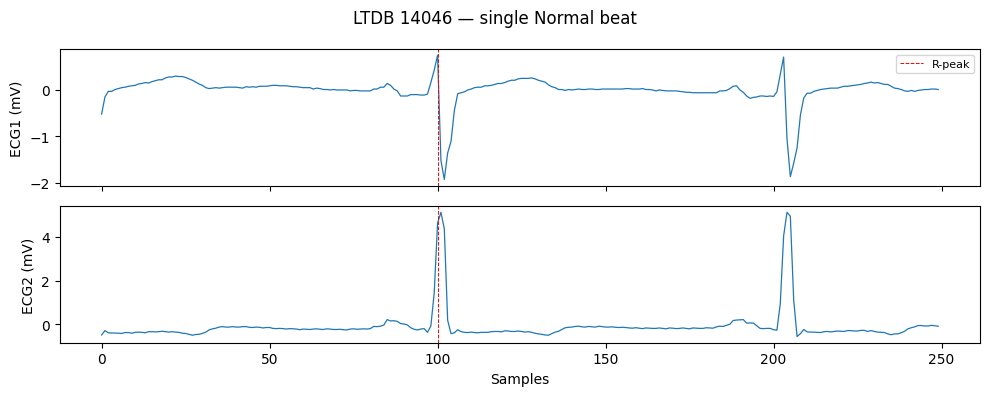

In [ ]:
# Plotting a single beat

rec = wfdb.rdrecord(str(LTDB_DIR / ltdb_records[0]))
ann = wfdb.rdann(str(LTDB_DIR / ltdb_records[0]), "atr")
sig = rec.p_signal

# find first N beat with enough room on both sides
r = None
for sample, sym in zip(ann.sample, ann.symbol):
    if sym == "N" and sample > 100 and sample + 150 < len(sig):
        r = sample
        break

print("R-peak used:", r)
window = sig[r-100 : r+150]

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for i, name in enumerate(rec.sig_name):
    axes[i].plot(window[:, i], lw=0.9)
    axes[i].axvline(100, color="red", lw=0.7, ls="--", label="R-peak")
    axes[i].set_ylabel(f"{name} (mV)")
axes[1].set_xlabel("Samples")
axes[0].legend(fontsize=8)
fig.suptitle(f"LTDB {ltdb_records[0]} — single Normal beat")
plt.tight_layout()
plt.show()

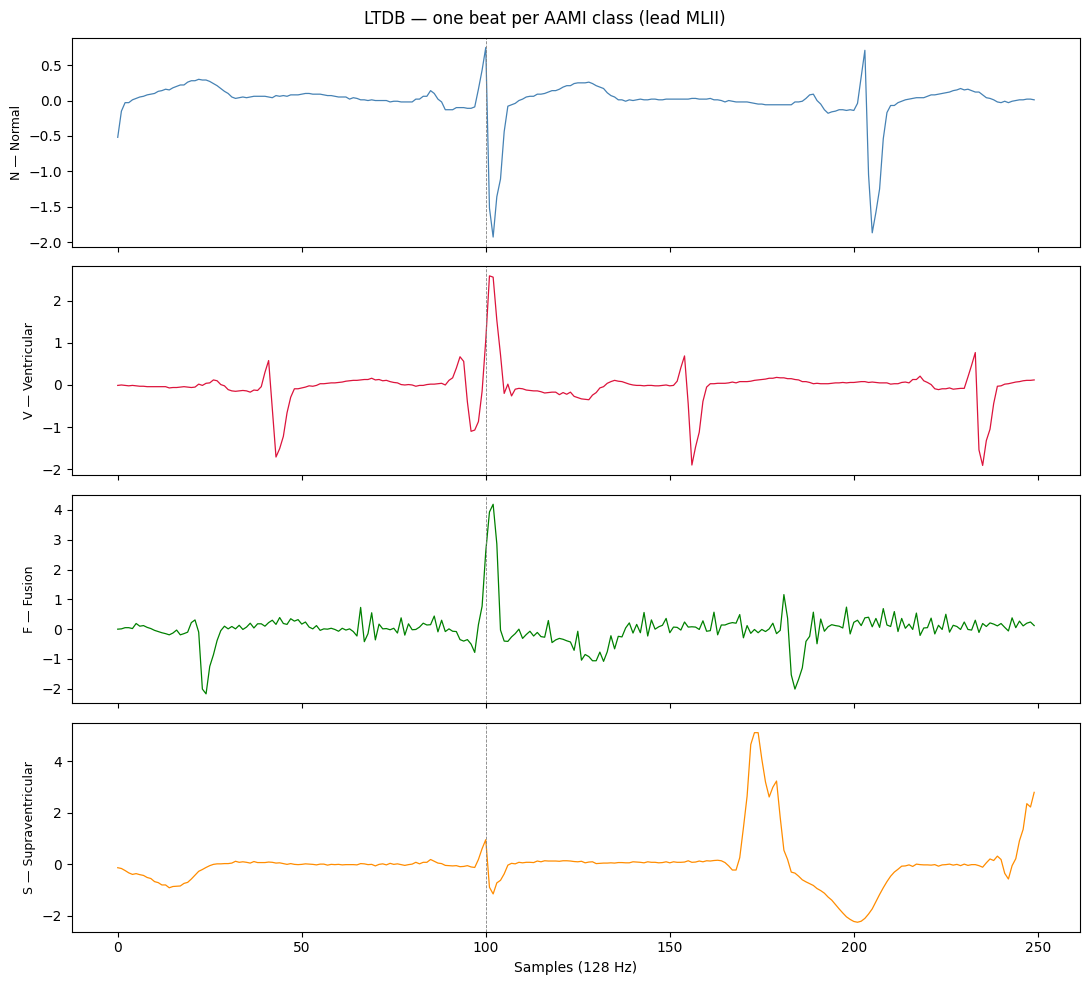

In [ ]:
# One beat per AAMI class
class_names = {"N": "N — Normal", "S": "S — Supraventricular", 
               "V": "V — Ventricular", "F": "F — Fusion"}

examples = {} # Collect one example per class
for name in ltdb_records:
    # Load signal + annotations
    rec = wfdb.rdrecord(str(LTDB_DIR / name))
    ann = wfdb.rdann(str(LTDB_DIR / name), "atr")
    sig = rec.p_signal
    
    # Find beats and map to AAMI
    for r, sym in zip(ann.sample, ann.symbol):
        if sym not in AAMI_MAP:
            continue
        cls = AAMI_MAP[sym]
        if cls not in examples and r > 100 and r + 150 < len(sig):
            examples[cls] = sig[r-100 : r+150, 0]
    if len(examples) == 4:
        break

n = len(examples)
colors = {"N":"steelblue", "S":"darkorange", "V":"crimson", "F":"green"}

fig, axes = plt.subplots(n, 1, figsize=(11, 2.5*n), sharex=True)
for ax, (cls, beat) in zip(axes, examples.items()):
    ax.plot(beat, lw=0.9, color=colors[cls])
    ax.axvline(100, color="gray", lw=0.6, ls="--")
    ax.set_ylabel(class_names[cls], fontsize=9)

axes[-1].set_xlabel("Samples (128 Hz)")
fig.suptitle("LTDB — one beat per AAMI class (lead MLII)")
plt.tight_layout()
plt.show()

In [ ]:
# PTB-XL metadata
import ast

meta = pd.read_csv(PTBXL_DIR / "ptbxl_database.csv", index_col="ecg_id")
meta["scp_codes"] = meta["scp_codes"].apply(ast.literal_eval)

In [43]:
print(f"Total records : {len(meta)}")
print(f"Columns       : {list(meta.columns)}\n")

Total records : 21799
Columns       : ['patient_id', 'age', 'sex', 'height', 'weight', 'nurse', 'site', 'device', 'recording_date', 'report', 'scp_codes', 'heart_axis', 'infarction_stadium1', 'infarction_stadium2', 'validated_by', 'second_opinion', 'initial_autogenerated_report', 'validated_by_human', 'baseline_drift', 'static_noise', 'burst_noise', 'electrodes_problems', 'extra_beats', 'pacemaker', 'strat_fold', 'filename_lr', 'filename_hr']



In [45]:
# PTB-XL superclass distribution
scp_df = pd.read_csv(PTBXL_DIR / "scp_statements.csv", index_col=0)

def get_superclass(scp_dict):
    out = []
    for code, conf in scp_dict.items():
        if conf >= 50 and code in scp_df.index:
            sc = scp_df.loc[code, "diagnostic_class"]
            if pd.notna(sc):
                out.append(sc)
    return list(set(out))

meta["superclass"] = meta["scp_codes"].apply(get_superclass)

sc_counts = meta["superclass"].explode().value_counts()
print("PTB-XL superclass counts:")
print(sc_counts)

PTB-XL superclass counts:
superclass
NORM    9438
STTC    5078
CD      4891
MI      4134
HYP     2258
Name: count, dtype: int64


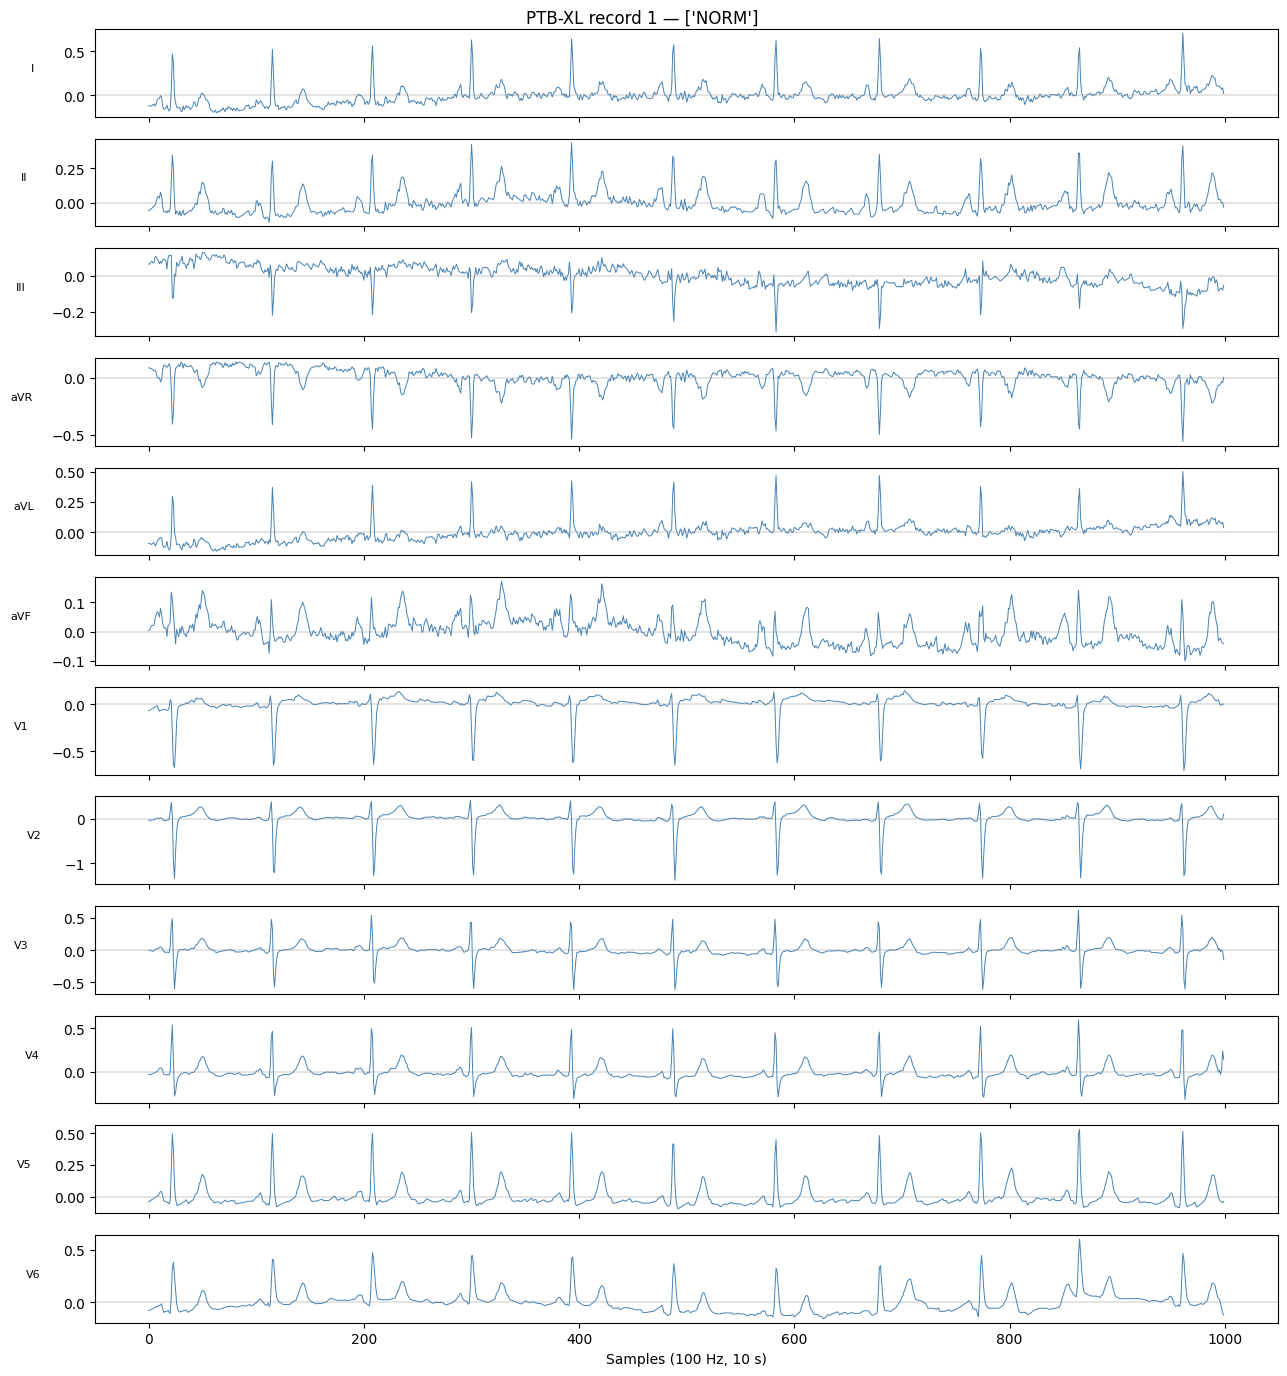

In [ ]:
# One 12-lead record
sample_row = meta.iloc[0]
rec = wfdb.rdrecord(str(PTBXL_DIR / sample_row.filename_lr))
sig = rec.p_signal   # (1000, 12)

lead_names = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]
fig, axes = plt.subplots(12, 1, figsize=(13, 14), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(sig[:, i], lw=0.7, color="steelblue")
    ax.set_ylabel(lead_names[i], fontsize=8, rotation=0, labelpad=22)
    ax.axhline(0, color="gray", lw=0.3)
axes[-1].set_xlabel("Samples (100 Hz, 10 s)")
fig.suptitle(f"PTB-XL record {sample_row.name} — {sample_row['superclass']}")
plt.tight_layout(); plt.show()

In [ ]:
# Summary table
print("=" * 45)
print(f"{'':20s}  {'LTDB':>10}  {'PTB-XL':>10}")
print("=" * 45)
print(f"{'Records':20s}  {len(ltdb_records):>10}  {len(meta):>10}")
print(f"{'Leads':20s}  {'2':>10}  {'12':>10}")
print(f"{'Sampling rate':20s}  {'128 Hz':>10}  {'100 Hz':>10}")
print(f"{'Clip length':20s}  {'~20 hrs':>10}  {'10 sec':>10}")
print(f"{'Label type':20s}  {'beat-level':>10}  {'record-level':>10}")
print(f"{'Classes':20s}  {'5 (AAMI)':>10}  {'5 super':>10}")
print("=" * 45)

                            LTDB      PTB-XL
Records                        7       21799
Leads                          2          12
Sampling rate             128 Hz      100 Hz
Clip length              ~20 hrs      10 sec
Label type            beat-level  record-level
Classes                 5 (AAMI)     5 super
